## Compare EDELWEISS to VIIRS

In [8]:
from edelassim.observations import EdelweissGrandesRoussesGrid

data_folder = "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses"
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m"
period = slice("2021-11-01", "2022-07-01")
grandesrousses_grid = EdelweissGrandesRoussesGrid()

In [16]:
import xarray as xr
from edelassim.bdclim import crop_bdclim, find_station_locations
from edelassim.observations import scale_virrs

forest_mask_path = f"{data_folder}/forest_mask/corine_grandesrousses_max.nc"
forest_mask = xr.open_dataarray(forest_mask_path, engine="rasterio").sel(band=1).drop_vars("band")

no_assim_all_path = f"{simulation_folder}/open_loop/all_members/pro/PRO_GrandesRousses250m_2021080206_2022080106.nc"
edel = xr.open_dataset(no_assim_all_path).where(forest_mask == 0).sel(time=period).data_vars["DSN_T_ISBA"]

viirs_filepath = f"{data_folder}/snow_cover/composite/regrid/mf_fsc_l3_grandesrousses_wy_2021_2022.nc"
viirs = scale_virrs(xr.open_dataset(viirs_filepath).where(forest_mask == 0).sel(time=period).data_vars["snow_cover_fraction"])

pleiades_path = f"{data_folder}/snow_depth/pleiades/pleiades_grandesrousses_all.nc"
pleiades = xr.open_dataset(pleiades_path).where(forest_mask == 0).sel(time=period).data_vars["snow_depth"]

bdclim_path = f"{data_folder}/snow_depth/bdclim/snow_depth_bdclim.nc"
bdclim = crop_bdclim(bdclim_path, grid=grandesrousses_grid).data_vars["neigetotx"].sel(time=period) / 100
x_poste, y_poste = find_station_locations(bdclim_dataset=bdclim)

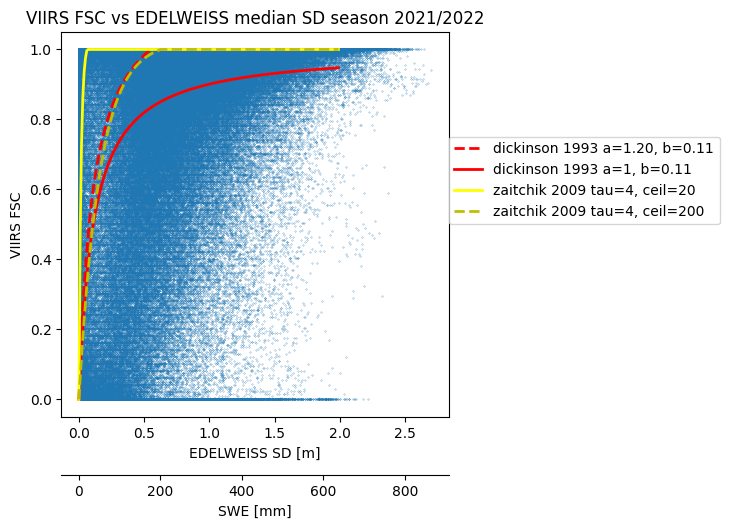

In [53]:
from matplotlib import pyplot as plt
import numpy as np
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe, swe_to_sd

fig, ax = plt.subplots(figsize=(5, 5))
sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"]).median(dim="member")
am, bm = 1.2, 0.11
tau, ceil = 4, 20
sd_axis = np.arange(0, 2, 0.01)  # m


swe_axis = sd_to_swe(sd_axis)


ax.scatter(sd, viirs, s=0.04)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=am, b=bm),
    "--r",
    linewidth=2,
    label=f"dickinson 1993 a={am:.2f}, b={bm:.2f}",
)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=1, b=0.11),
    "r",
    linewidth=2,
    label="dickinson 1993 a=1, b=0.11",
)
ax.plot(
    sd_axis,
    zaitchik(swe=swe_axis, tau_scf=tau, swe_full_snow_cover=ceil),
    "yellow",
    linewidth=2,
    label=f"zaitchik 2009 tau={tau}, ceil={ceil}",
)
ax.plot(
    sd_axis,
    zaitchik(swe=swe_axis, tau_scf=tau, swe_full_snow_cover=200),
    "--y",
    linewidth=2,
    label=f"zaitchik 2009 tau={tau}, ceil={200}",
)
# ax.plot(np.arange(0, 2, 0.01), dickinson(sd=np.arange(0, 2, 0.01), a=am, b=bm), "r", linewidth=2)
ax.set_title("VIIRS FSC vs EDELWEISS median SD season 2021/2022")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("EDELWEISS SD [m]")
secax = ax.secondary_xaxis(-0.15, functions=(sd_to_swe, swe_to_sd))
secax.set_xlabel("SWE [mm]")
ax.legend(loc=(1, 0.5))

In [18]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.axes import Axes
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np


def draw_member_clorbar(n_members: int, aax: Axes, colormap: plt.Colormap):

    divider = make_axes_locatable(aax)
    ax_cb = divider.new_horizontal(size="5%", pad=0.05)
    members = np.arange(n_members)
    cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=colormap.resampled(n_members), orientation="vertical")
    cbar.ax.set_yticks(members / n_members)
    cbar.ax.set_yticklabels(members)
    cbar.set_label("# member")
    plt.gcf().add_axes(ax_cb)


colormap = plt.cm.viridis  # nipy_spectral, Set1,Paired
colorst = [colormap(i) for i in np.linspace(0, 1, 17)]
a0, b0 = 1, 0.11
a_calib, b_calib = 1.2, 0.11
tau0, ceil0 = 4, 20
tau_calib, ceil_calib = 4, 200

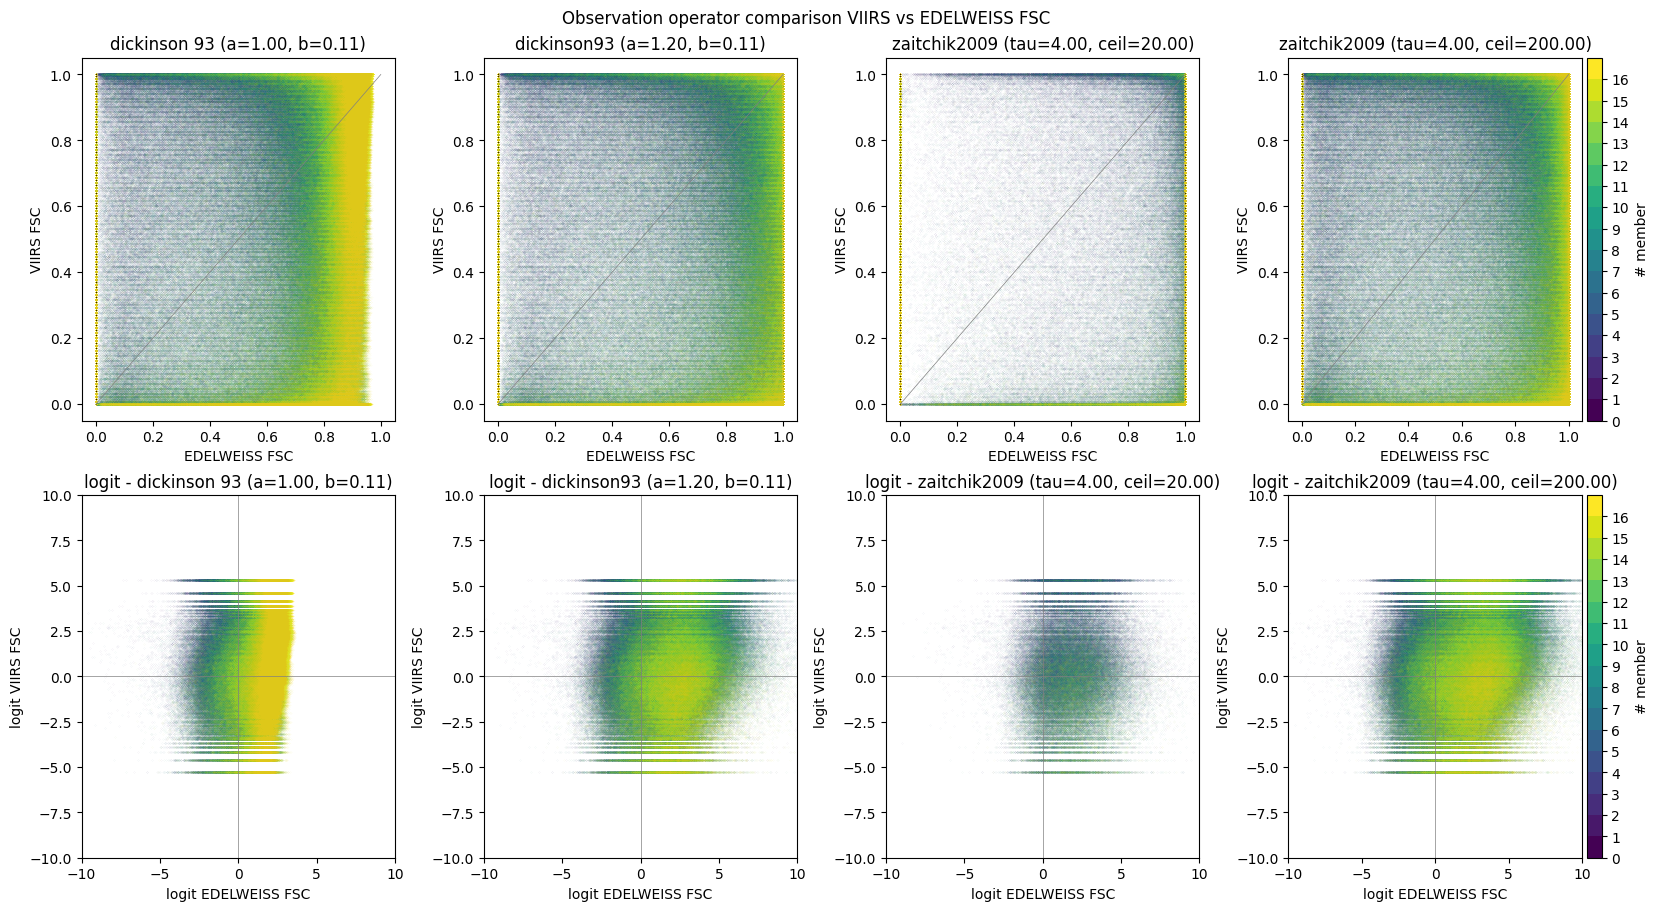

In [7]:
import matplotlib.pyplot as plt
from scipy.special import logit
import numpy as np
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe

fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Observation operator comparison VIIRS vs EDELWEISS FSC")
edel_sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"])


viirs_flatten = viirs.values.ravel()

for member in edel_sd.coords["member"]:
    edel_fsc = dickinson(edel_sd.sel(member=member), a0, b0).values.ravel()
    axs[0, 0].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 0].set_title(f"dickinson 93 (a={a0:.2f}, b={b0:.2f})")
    axs[1, 0].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 0].set_title(f"logit - dickinson 93 (a={a0:.2f}, b={b0:.2f})")

for member in edel_sd.coords["member"]:
    edel_fsc = dickinson(edel_sd.sel(member=member), a_calib, b_calib).values.ravel()
    axs[0, 1].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 1].set_title(f"dickinson93 (a={a_calib:.2f}, b={b_calib:.2f})")
    axs[1, 1].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 1].set_title(f"logit - dickinson93 (a={a_calib:.2f}, b={b_calib:.2f})")

for member in edel_sd.coords["member"]:
    edel_fsc = zaitchik(sd_to_swe(edel_sd.sel(member=member)), tau_scf=tau0, swe_full_snow_cover=ceil0).values.ravel()
    axs[0, 2].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 2].set_title(f"zaitchik2009 (tau={tau0:.2f}, ceil={ceil0:.2f})")
    axs[1, 2].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 2].set_title(f"logit - zaitchik2009 (tau={tau0:.2f}, ceil={ceil0:.2f})")


for member in edel_sd.coords["member"]:
    edel_fsc = zaitchik(
        sd_to_swe(edel_sd.sel(member=member)), tau_scf=tau_calib, swe_full_snow_cover=ceil_calib
    ).values.ravel()
    axs[0, 3].plot(edel_fsc, viirs_flatten, ".", color=colorst[member.values], markersize=0.04)
    axs[0, 3].set_title(f"zaitchik2009 (tau={tau_calib:.2f}, ceil={ceil_calib:.2f})")
    axs[1, 3].plot(logit(edel_fsc), logit(viirs_flatten), ".", color=colorst[member.values], markersize=0.04)
    axs[1, 3].set_title(f"logit - zaitchik2009 (tau={tau_calib:.2f}, ceil={ceil_calib:.2f})")

draw_member_clorbar(n_members=edel_sd.sizes["member"], aax=axs[0, 3], colormap=colormap)
draw_member_clorbar(n_members=edel_sd.sizes["member"], aax=axs[1, 3], colormap=colormap)

for ax in axs[0, :]:
    ax.plot([0, 1], [0, 1], "gray", linewidth=0.5)
    ax.set_xlabel("EDELWEISS FSC")
    ax.set_ylabel("VIIRS FSC")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)


for ax in axs[1, :]:
    ax.plot([-10, 10], [0, 0], "gray", linewidth=0.5)
    ax.plot([0, 0], [-10, 10], "gray", linewidth=0.5)
    ax.set_xlabel("logit EDELWEISS FSC")
    ax.set_ylabel("logit VIIRS FSC")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)


/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_logit.legend()
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_logit.legend()
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_logit.legend()
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:24: UserWarning: No artists with labels found to put in legend.  Note 

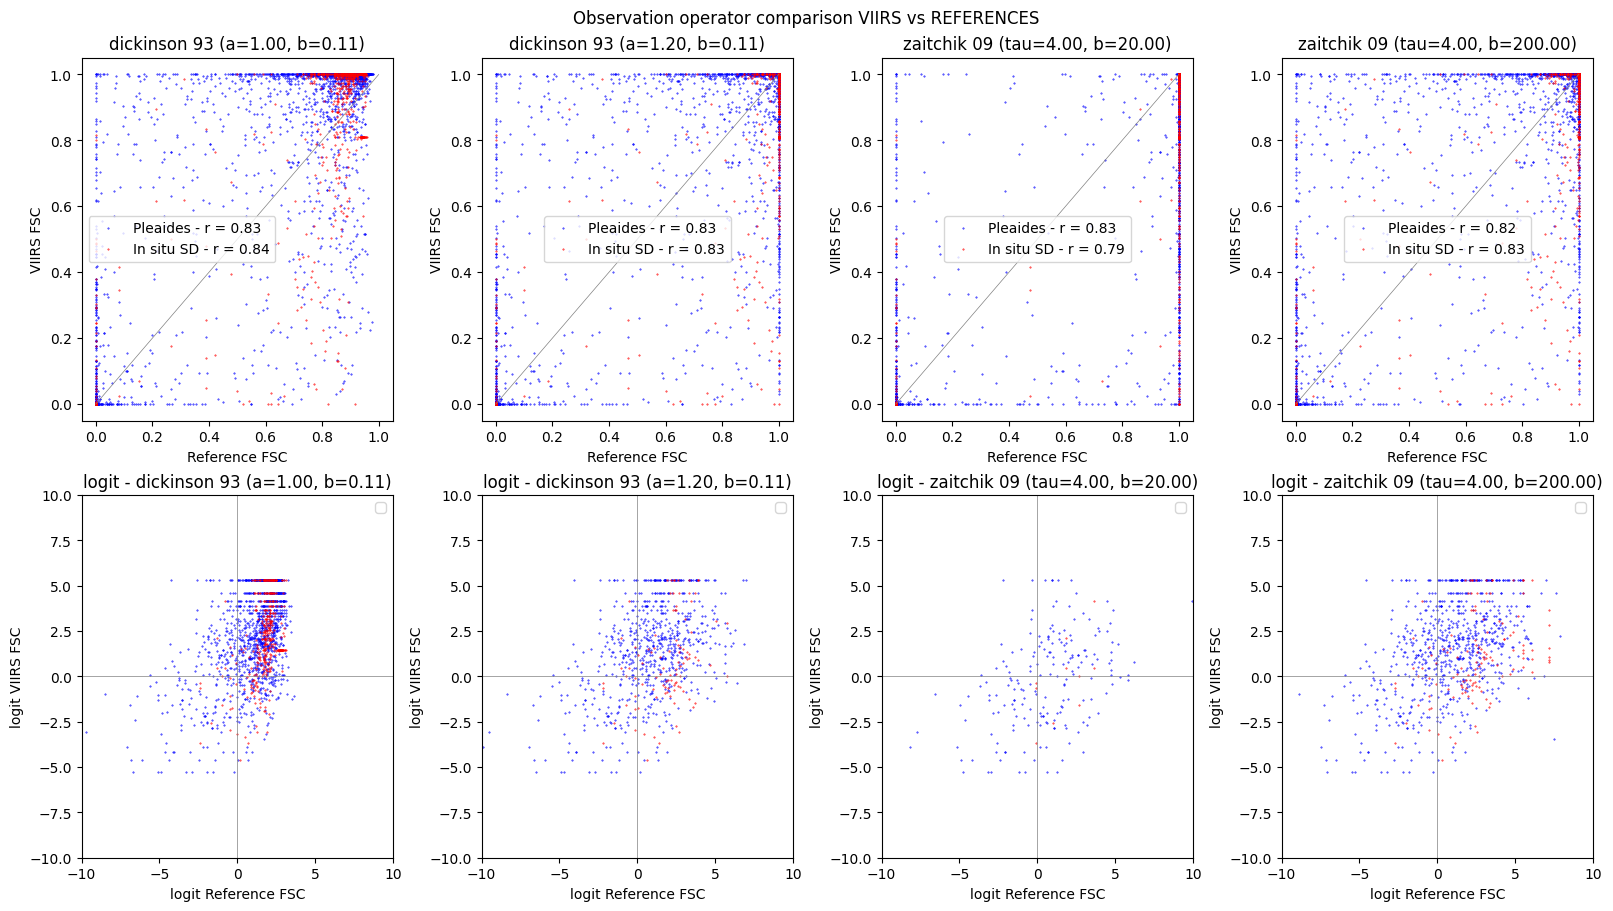

In [ ]:
import matplotlib.pyplot as plt
from edelassim.evaluations import find_common_correspondences
from edelassim.observation_operators import dickinson, zaitchik
from edelassim.swe import sd_to_swe
from edelassim.visualization import scatter_logit_plot

fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Observation operator comparison VIIRS vs REFERENCES")

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest").sel(band=1)
sd_pleaides = sd_pleaides.where(sd_pleaides >= 0)
sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest").assign_coords({"time": sd_bdclim.time})
viirs_pleaides_passes = viirs.sel(time=pleiades.coords["time"], method="nearest").assign_coords({"time": pleiades.time})


def viirs_vs_pleaides_bdclim_scatter(
    viirs_pleiades_passes_obs, pleiades_obs, viirs_station_obs, bdclim_obs, title, ax_normal, ax_logit
):
    """Boilerplate code."""
    scatter_logit_plot(
        data1=pleiades_obs,
        data2=viirs_pleiades_passes_obs,
        ax_normal=ax_normal,
        ax_logit=ax_logit,
        color="b",
        title=title,
        label="Pleiades",
    )

    scatter_logit_plot(
        data1=bdclim_obs,
        data2=viirs_station_obs,
        ax_normal=ax_normal,
        ax_logit=ax_logit,
        color="r",
        title=title,
        label="In situ SD",
    )


# Dickinson orig
title_d93 = f"dickinson 93 (a={a0:.2f}, b={b0:.2f})"
fsc_bdclim = dickinson(sd_bdclim, a0, b0)
fsc_pleaides = dickinson(sd_pleaides, a0, b0)

viirs_vs_pleaides_bdclim_scatter(
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_d93,
    ax_normal=axs[0, 0],
    ax_logit=axs[1, 0],
)

# Dickinson calib
fsc_bdclim = dickinson(sd_bdclim, a_calib, b_calib)
fsc_pleaides = dickinson(sd_pleaides, a_calib, b_calib)
title_d93 = f"dickinson 93 (a={a_calib:.2f}, b={b_calib:.2f})"

viirs_vs_pleaides_bdclim_scatter(
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_d93,
    ax_normal=axs[0, 1],
    ax_logit=axs[1, 1],
)

# Zaitchik orig
# We convert with a "mean snow density" of 320 kg/m^2
title_z93 = f"zaitchik 09 (tau={tau0:.2f}, b={ceil0:.2f})"
fsc_bdclim = zaitchik(sd_to_swe(sd_bdclim), tau0, ceil0)
fsc_pleaides = zaitchik(sd_to_swe(sd_pleaides), tau0, ceil0)

viirs_vs_pleaides_bdclim_scatter(
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_z93,
    ax_normal=axs[0, 2],
    ax_logit=axs[1, 2],
)

title_z93 = f"zaitchik 09 (tau={tau_calib:.2f}, b={ceil_calib:.2f})"
fsc_bdclim = zaitchik(sd_to_swe(sd_bdclim), tau_calib, ceil_calib)
fsc_pleaides = zaitchik(sd_to_swe(sd_pleaides), tau_calib, ceil_calib)

viirs_vs_pleaides_bdclim_scatter(
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_z93,
    ax_normal=axs[0, 3],
    ax_logit=axs[1, 3],
)

for ax in axs[0, :]:
    ax.plot([0, 1], [0, 1], "gray", linewidth=0.5)
    ax.set_xlabel("Reference FSC")
    ax.set_ylabel("VIIRS FSC")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)


for ax in axs[1, :]:
    ax.plot([-10, 10], [0, 0], "gray", linewidth=0.5)
    ax.plot([0, 0], [-10, 10], "gray", linewidth=0.5)
    ax.set_xlabel("logit Reference FSC")
    ax.set_ylabel("logit VIIRS FSC")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)


/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:50: RuntimeWarning: invalid value encountered in subtract
  residuals_logit = logit(data2_correspondences) - logit(data1_correspondences)
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_normal.legend()
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_logit.legend()
/home/imperatoren/work/edelweiss_assimilation/edelassim/src/edelassim/visualization.py:50: RuntimeWarning: invalid value encountered in subtract
  residuals_logit = logit(data2_correspondences) - logit(data1_corr

Dickinson orig always slightly positive bias irrespectively of the comparison
For all the others, at least the median is at 0
The calibrated have some members that have positive residual distribution and other that have a negative one. That's what we expect?
zaitchik orig VIIRS always gives less snow than the model -> expected too
Dickinson orig never reaches 100, probably underestimates fractions, so VIIRS has always more
Zaitchik orig gives 100 even with little snow, probbly overestimate fraction, so VIIRS gives always less


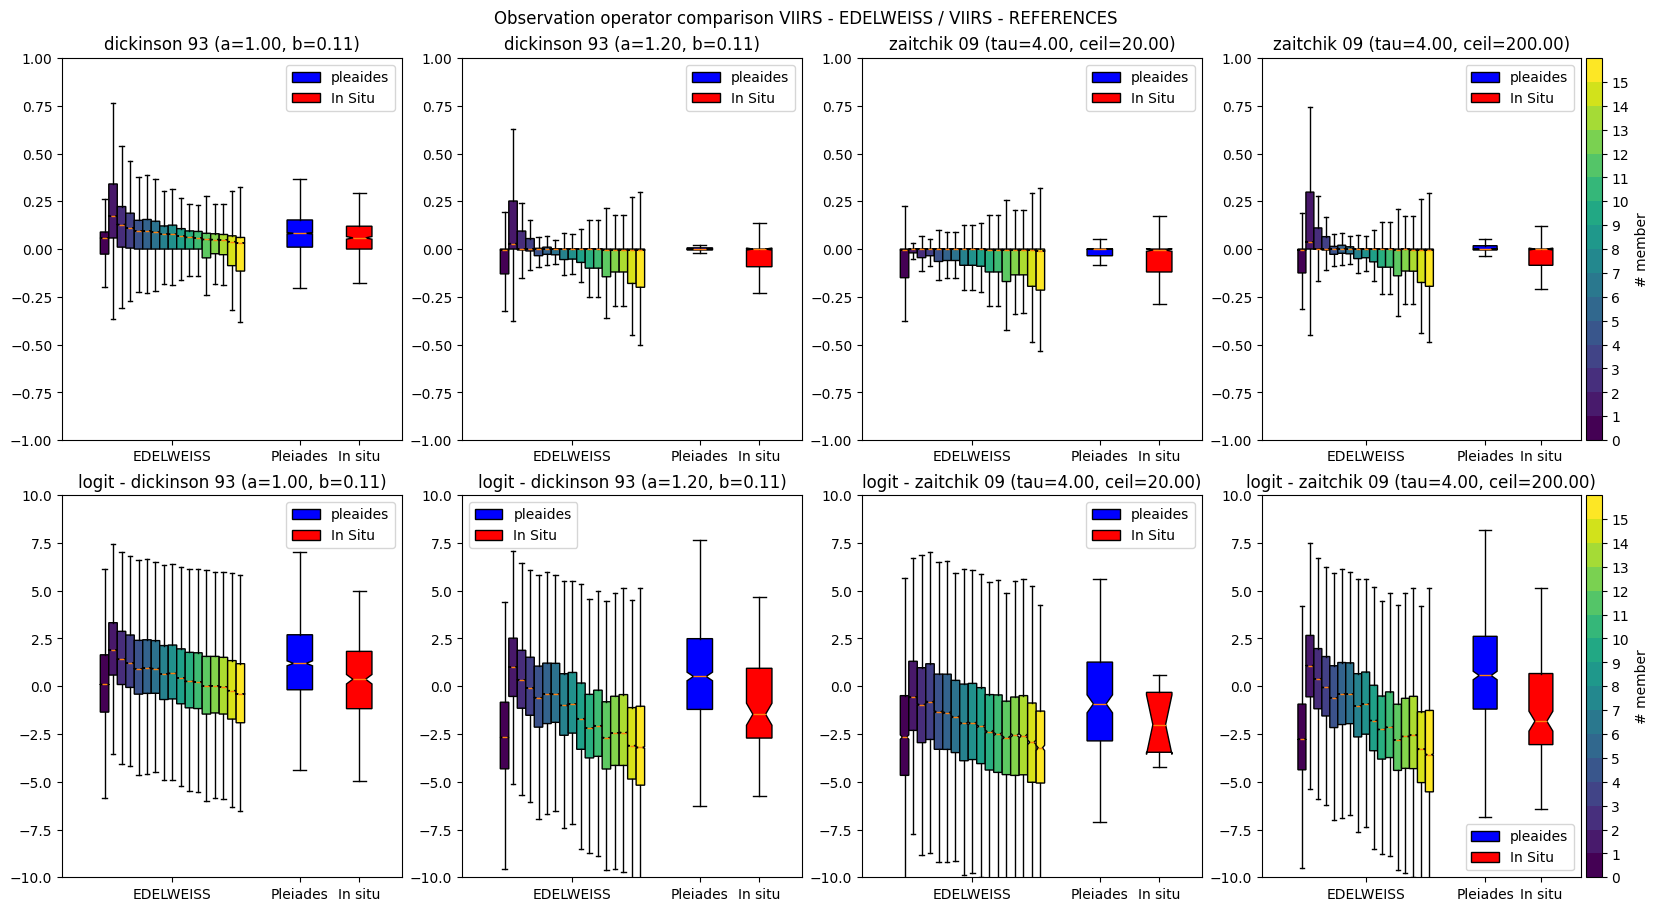

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from edelassim.visualization import boxplot_logit_plot

fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Observation operator comparison VIIRS - EDELWEISS / VIIRS - REFERENCES")

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest").sel(band=1)
sd_pleaides = sd_pleaides.where(sd_pleaides >= 0)
sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest").assign_coords({"time": sd_bdclim.time})
viirs_pleaides_passes = viirs.sel(time=pleiades.coords["time"], method="nearest").assign_coords({"time": pleiades.time})
n_members = edel_sd.coords["member"][-1]


def boxplot_residuals_viirs_edel_pleaides_bdclim(
    viirs_edel_time,
    edel_all_member,
    viirs_pleiades_passes_obs,
    pleiades_obs,
    viirs_station_obs,
    bdclim_obs,
    title,
    ax_normal,
    ax_logit,
):
    colormap = plt.cm.viridis  # nipy_spectral, Set1,Paired
    color_list = [colormap(i) for i in np.linspace(0, 1, edel_all_member.sizes["member"])]

    for member in edel_all_member.coords["member"].values:
        boxplot_logit_plot(
            data1=edel_all_member.sel(member=member),
            data2=viirs_edel_time,
            ax_normal=ax_normal,
            ax_logit=ax_logit,
            color=color_list[member],
            title=title,
            pos=[member],
            width=[1],
        )

    boxplot_logit_plot(
        data1=pleiades_obs,
        data2=viirs_pleiades_passes_obs,
        ax_normal=ax_normal,
        ax_logit=ax_logit,
        color="b",
        title=title,
        pos=[n_members + 7],
        width=[3],
        label="pleaides",
    )

    boxplot_logit_plot(
        data1=bdclim_obs,
        data2=viirs_station_obs,
        ax_normal=ax_normal,
        ax_logit=ax_logit,
        color="r",
        title=title,
        pos=[n_members + 14],
        width=[3],
        label="In Situ",
    )


# Dickinson orig
edel_fsc = dickinson(edel_sd, a0, b0)
fsc_pleaides = dickinson(sd_pleaides, a0, b0)
fsc_bdclim = dickinson(sd_bdclim, a0, b0)
title_d93 = f"dickinson 93 (a={a0:.2f}, b={b0:.2f})"
boxplot_residuals_viirs_edel_pleaides_bdclim(
    viirs_edel_time=viirs.assign_coords(time=edel_fsc.coords["time"]),
    edel_all_member=edel_fsc,
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_d93,
    ax_normal=axs[0, 0],
    ax_logit=axs[1, 0],
)

# Dickinson calib
edel_fsc = dickinson(edel_sd, a_calib, b_calib)
fsc_pleaides = dickinson(sd_pleaides, a_calib, b_calib)
fsc_bdclim = dickinson(sd_bdclim, a_calib, b_calib)
title_d93 = f"dickinson 93 (a={a_calib:.2f}, b={b_calib:.2f})"
boxplot_residuals_viirs_edel_pleaides_bdclim(
    viirs_edel_time=viirs.assign_coords(time=edel_fsc.coords["time"]),
    edel_all_member=edel_fsc,
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_d93,
    ax_normal=axs[0, 1],
    ax_logit=axs[1, 1],
)

# Zaitchik orig
edel_fsc = zaitchik(swe=sd_to_swe(edel_sd), tau_scf=tau0, swe_full_snow_cover=ceil0)
fsc_pleaides = zaitchik(swe=sd_to_swe(sd_pleaides), tau_scf=tau0, swe_full_snow_cover=ceil0)
fsc_bdclim = zaitchik(swe=sd_to_swe(sd_bdclim), tau_scf=tau0, swe_full_snow_cover=ceil0)
title_z09 = f"zaitchik 09 (tau={tau0:.2f}, ceil={ceil0:.2f})"
boxplot_residuals_viirs_edel_pleaides_bdclim(
    viirs_edel_time=viirs.assign_coords(time=edel_fsc.coords["time"]),
    edel_all_member=edel_fsc,
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_z09,
    ax_normal=axs[0, 2],
    ax_logit=axs[1, 2],
)

# Zaitchik calib
edel_fsc = zaitchik(swe=sd_to_swe(edel_sd), tau_scf=tau_calib, swe_full_snow_cover=ceil_calib)
fsc_pleaides = zaitchik(swe=sd_to_swe(sd_pleaides), tau_scf=tau_calib, swe_full_snow_cover=ceil_calib)
fsc_bdclim = zaitchik(swe=sd_to_swe(sd_bdclim), tau_scf=tau_calib, swe_full_snow_cover=ceil_calib)
title_z09 = f"zaitchik 09 (tau={tau_calib:.2f}, ceil={ceil_calib:.2f})"
boxplot_residuals_viirs_edel_pleaides_bdclim(
    viirs_edel_time=viirs.assign_coords(time=edel_fsc.coords["time"]),
    edel_all_member=edel_fsc,
    viirs_pleiades_passes_obs=viirs_pleaides_passes,
    pleiades_obs=fsc_pleaides,
    viirs_station_obs=viirs_station,
    bdclim_obs=fsc_bdclim,
    title=title_z09,
    ax_normal=axs[0, 3],
    ax_logit=axs[1, 3],
)


for axrow in axs:
    for ax in axrow:
        ax.set_xlim(-5, 35)
        ax.set_xticks([n_members / 2, n_members + 7, n_members + 14])
        ax.set_xticklabels(["EDELWEISS", "Pleiades", "In situ"])

for ax in axs[0, :]:
    ax.set_ylim(-1, 1)

for ax in axs[1, :]:
    ax.set_ylim(-10, 10)

draw_member_clorbar(n_members=n_members.values, aax=axs[0, 3], colormap=colormap)
draw_member_clorbar(n_members=n_members.values, aax=axs[1, 3], colormap=colormap)

print("Dickinson orig always slightly positive bias irrespectively of the comparison")
print("For all the others, at least the median is at 0")
print(
    "The calibrated have some members that have positive residual distribution and other that have a negative one. That's what we expect?"
)
print("zaitchik orig VIIRS always gives less snow than the model -> expected too")
print("Dickinson orig never reaches 100, probably underestimates fractions, so VIIRS has always more")
print("Zaitchik orig gives 100 even with little snow, probbly overestimate fraction, so VIIRS gives always less")

In [38]:
from mountain_data_binner.mountain_binner import MountainBinner, MountainBinnerConfig
from edelassim.observation_operators import dickinson

aux_data_folder = "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary"
mb = MountainBinner(
    MountainBinnerConfig(
        slope_map_path=f"{aux_data_folder}/topography/slope.tif",
        aspect_map_path=f"{aux_data_folder}/topography/aspect.tif",
        dem_path=f"{aux_data_folder}/topography/dem.tif",
        forest_mask_path=f"{aux_data_folder}/forest_mask/forest_mask.tif",
    )
)

viirs_edel_ds = xr.Dataset(
    {"viirs": viirs.assign_coords(time=edel_sd.coords["time"]), "edel": dickinson(edel_sd, a=a_calib, b=b_calib)}
)
# residuals = viirs.assign_coords(time=edel_sd.coords["time"]) - dickinson(edel_sd, a=a_calib, b=b_calib)

In [83]:
aspect_map = xr.open_dataarray(f"{aux_data_folder}/topography/aspect.tif").sel(band=1)
slope_map = xr.open_dataarray(f"{aux_data_folder}/topography/slope.tif").sel(band=1)
dem_map = xr.open_dataarray(f"{aux_data_folder}/topography/dem.tif").sel(band=1)
forest_mask = xr.open_dataarray(f"{aux_data_folder}/forest_mask/forest_mask.tif").sel(band=1)

(-10.0, 10.0)

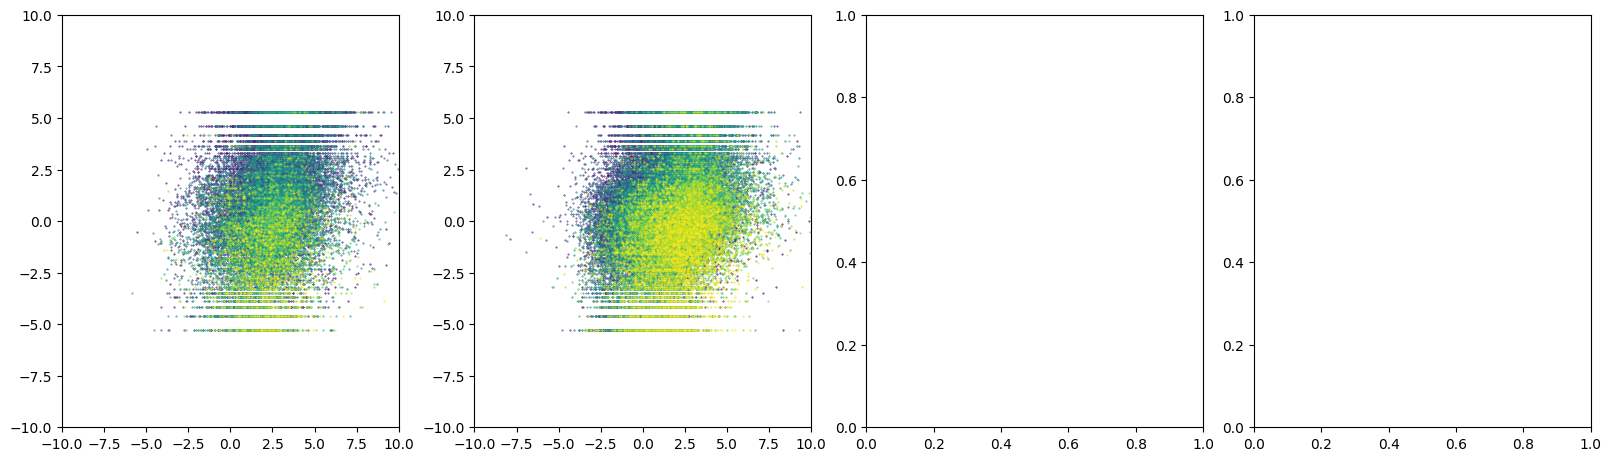

In [ ]:
# Nord, sud etc
# from typing import List
from typing import List
import xarray as xr
import numpy as np
from matplotlib.axes import Axes
import matplotlib.pyplot as plt


def scatter_fsc_logit(ds: xr.Dataset, axes: List[Axes]):
    n_members = ds.sizes["member"]
    colormap = plt.cm.viridis  # nipy_spectral, Set1,Paired
    colorst = [colormap(i) for i in np.linspace(0, 1, n_members)]
    for m in range(n_members):
        data1_correspondences, data2_correspondences = find_common_correspondences(
            data_1=ds.data_vars["edel"].sel(member=m), data_2=ds.data_vars["viirs"]
        )
        data1_correspondences = data1_correspondences.ravel()
        data2_correspondences = data2_correspondences.ravel()
        # print(data2_correspondences.mean())
        axes.plot(logit(data1_correspondences), logit(data2_correspondences), ".", color=colorst[m], markersize=0.8)


fig, ax = plt.subplots(1, 4, figsize=(16, 4.5), constrained_layout=True)

scatter_fsc_logit(ds=viirs_edel_ds.where((aspect_map > 337.5)), axes=ax[0])
scatter_fsc_logit(ds=viirs_edel_ds.where(aspect_map > 167.5).where(aspect_map < 180), axes=ax[1])
ax[0].set_xlim(-10, 10)
ax[0].set_ylim(-10, 10)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-10, 10)

(-10.0, 10.0)

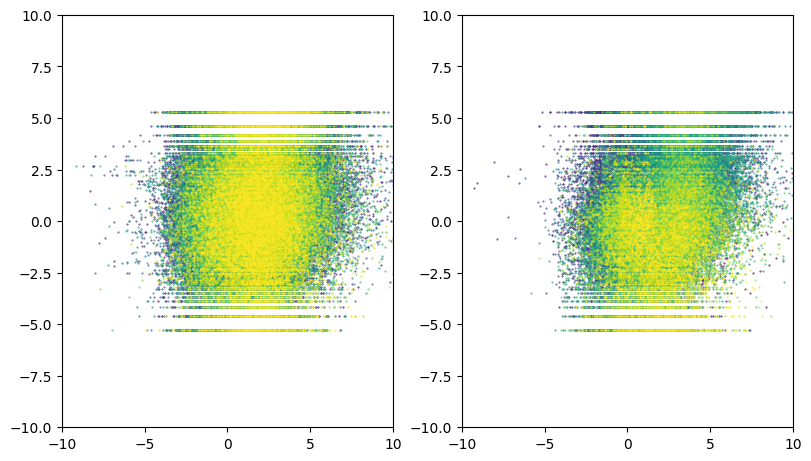

In [ ]:
# slope
fig, ax = plt.subplots(1, 2, figsize=(8, 4.5), constrained_layout=True)

scatter_fsc_logit(ds=viirs_edel_ds.where((slope_map > 30)), axes=ax[0])
scatter_fsc_logit(ds=viirs_edel_ds.where(slope_map < 10), axes=ax[1])
ax[0].set_xlim(-10, 10)
ax[0].set_ylim(-10, 10)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-10, 10)

(-10.0, 10.0)

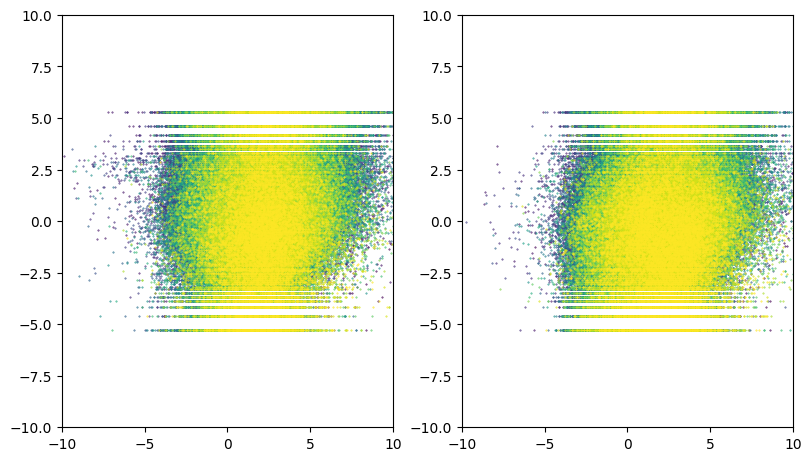

In [ ]:
# Altitude
fig, ax = plt.subplots(1, 2, figsize=(8, 4.5), constrained_layout=True)

scatter_fsc_logit(ds=viirs_edel_ds.where((dem_map > 2000)), axes=ax[0])
scatter_fsc_logit(ds=viirs_edel_ds.where(dem_map < 2000), axes=ax[1])
ax[0].set_xlim(-10, 10)
ax[0].set_ylim(-10, 10)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-10, 10)

In [85]:
forest_mask

<xarray.DataArray 'band_data' (y: 101, x: 143)> Size: 58kB
array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 1., ..., 1., 1., 1.],
       [0., 0., 1., ..., 1., 1., 1.],
       [0., 1., 1., ..., 1., 1., 1.]], shape=(101, 143), dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 1kB 9.379e+05 9.381e+05 ... 9.731e+05 9.734e+05
  * y            (y) float64 808B 6.464e+06 6.464e+06 ... 6.439e+06 6.439e+06
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area

(-10.0, 10.0)

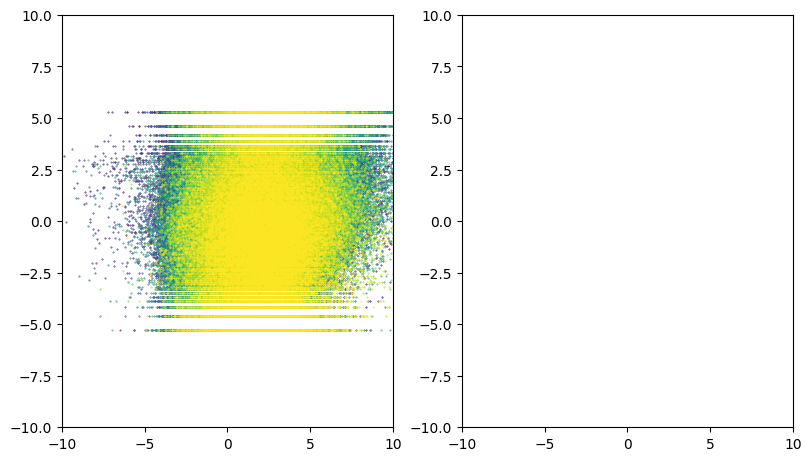

In [84]:
# Altitude
fig, ax = plt.subplots(1, 2, figsize=(8, 4.5), constrained_layout=True)

scatter_fsc_logit(ds=viirs_edel_ds.where((forest_mask == 0)), axes=ax[0])
scatter_fsc_logit(ds=viirs_edel_ds.where(forest_mask == 1), axes=ax[1])
ax[0].set_xlim(-10, 10)
ax[0].set_ylim(-10, 10)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-10, 10)